# La idea de Francisco: super-nodos PWT y restricción de W

*Notebook explicativo, idea simple → resultados.*

Este notebook explica paso a paso una propuesta de Francisco
Marmolejo para darle a *Greedy Dynamic* una mejor garantía teórica,
y muestra qué tanto funciona en la práctica.

**Puntos que vamos a cubrir, en orden:**

1. La idea: tomar lo ya cubierto por las pruebas anteriores y
   empaquetarlo como "super-nodos" para reformular el problema de
   elegir el siguiente pool.
2. Verificar que la formulación con probabilidad "all-clear" reproduce
   exactamente al greedy myopic actual.
3. Encontrar el defecto: dos subconjuntos con el mismo *resumen
   escalar* pueden tener distinto valor de información.
4. Medir el *lookahead gap* (greedy vs DP óptimo) y mostrar que la
   formulación escalar de PWT no lo cierra.
5. Q3 — ¿se puede restringir W (que es 2^|S|) a un top-L sin perder el
   óptimo? Probamos varias heurísticas.
6. Construir un caso adversarial donde la heurística obvia falla, y
   mostrar que un mejor ranking (`partner`) lo resuelve.
7. Sweep de robustez en 6 regímenes para ver si `partner` aguanta.


## 1. Setup

In [1]:
import os, sys
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

from augmented.core import (
    indices_from_mask, mask_from_indices, test_result,
)
from augmented.bayesian import (
    _poisson_binomial_pmf, bayesian_update_single_test,
)
from augmented.greedy import greedy_myopic_simulate
from augmented.solver import solve_optimal_dapts
from augmented.pwt_demo import (
    _pool_score_myopic, _enumerate_full_pools, _enumerate_pwt,
)
from augmented.pwt_restrict import (
    restriction_experiment, adversarial_instance,
)
from augmented.pwt_restrict_sweep import REGIMES, run_regime


## 2. La idea de Francisco — en una imagen

Tenemos:
- Población $N$, presupuesto de pruebas $B$, tamaño máximo de pool $G$.
- Resultado del test es **aumentado**: $r(t, Z) = |t \cap Z|$ — el conteo
  exacto de infectados en el pool, no sólo "positivo / negativo".

Después de hacer $k$ pruebas tenemos:
- $S$ = unión de los pools usados (gente que ya tocamos).
- $V = N \setminus S$ (gente que no hemos tocado).

**Idea:** para cada subconjunto $T \subseteq S$, agregar un "super-nodo"
$w_T$ con:
- peso $|T|$
- probabilidad $\prod_{i \in T}(1 - p_i)$ (todos limpios)
- utilidad $\sum_{i \in T} u_i$

Y definir el problema de "siguiente pool" sobre $V \cup W$, con la
restricción **|t ∩ W| ≤ 1** (a lo más un super-nodo). La idea es que
si tenemos una $\alpha$-aproximación para este problema-de-un-paso
(*PWT*), componiéndola por los $B$ pasos obtendríamos una garantía
$\sim (1 - e^{-\alpha})$ para Greedy Dynamic.


## 3. Instancia concreta y paso 1

Vamos a usar una instancia chica donde podamos calcular todo a mano:
$n = 6$, $G = 3$, $B = 2$. Probabilidades bajas, utilidades variadas.

In [2]:
n, G, B = 6, 3, 2
p_prior = [0.10, 0.15, 0.20, 0.08, 0.12, 0.25]
u = [4.0, 6.0, 3.0, 5.0, 7.0, 4.0]

print(f"n={n}, G={G}, B={B}")
print(f"p_prior = {p_prior}")
print(f"u       = {u}")


n=6, G=3, B=2
p_prior = [0.1, 0.15, 0.2, 0.08, 0.12, 0.25]
u       = [4.0, 6.0, 3.0, 5.0, 7.0, 4.0]


Hacemos la primera prueba sobre el pool $\{0, 2, 4\}$ y supongamos
que observamos $r = 1$ (uno de ellos infectado). Eso fija
$S = \{0, 2, 4\}$ y $V = \{1, 3, 5\}$, y actualizamos las
probabilidades con Bayes.

In [3]:
pool1 = mask_from_indices([0, 2, 4])
z_true = mask_from_indices([2])  # individuo 2 realmente infectado
r1 = test_result(pool1, z_true)
p_post = bayesian_update_single_test(p_prior, pool1, r1, n)

S_idx = indices_from_mask(pool1, n)
V_idx = [i for i in range(n) if i not in S_idx]

print(f"Step 1: tested {S_idx}, observed r1 = {r1}")
print(f"posterior p = {[round(x, 4) for x in p_post]}")
print(f"S = {S_idx}, V = {V_idx}")


Step 1: tested [0, 2, 4], observed r1 = 1
posterior p = [0.2234, 0.15, 0.5025, 0.08, 0.2741, 0.25]
S = [0, 2, 4], V = [1, 3, 5]


## 4. Tres formulaciones del paso 2

Ahora hay que elegir el segundo pool. Las tres formulaciones que
probamos:

- **Enumeración completa**: revisar todos los pools $t \subseteq N$ con
  $|t| \le G$ y maximizar $(\sum u_t) \cdot \prod (1 - p_t)$.
- **PWT-A** (lectura "all-clear"): super-nodo $w_T$ con probabilidad
  $\prod_{i \in T}(1 - p_i)$.
- **PWT-B** (lectura "OR-event" — la que asumió Codex): probabilidad
  $1 - \prod_{i \in T}(1 - p_i)$.

In [4]:
pool_full, val_full = _enumerate_full_pools(S_idx, V_idx, p_post, u, G)
pool_A, val_A = _enumerate_pwt(S_idx, V_idx, p_post, u, G, "all_clear")
pool_B, val_B = _enumerate_pwt(S_idx, V_idx, p_post, u, G, "or_event")

print(f"  enumeración completa : pool = {indices_from_mask(pool_full)}, "
      f"val = {val_full:.4f}")
print(f"  PWT-A (all-clear)    : pool = {indices_from_mask(pool_A)}, "
      f"val = {val_A:.4f}")
print(f"  PWT-B (OR-event)     : pool = {indices_from_mask(pool_B)}, "
      f"val = {val_B:.4f}")
print()
print(f"  PWT-A val == full ?  {abs(val_A - val_full) < 1e-9}")
print(f"  PWT-B val == full ?  {abs(val_B - val_full) < 1e-9}")


  enumeración completa : pool = [1, 3, 4], val = 10.2176
  PWT-A (all-clear)    : pool = [1, 3, 4], val = 10.2176
  PWT-B (OR-event)     : pool = [0, 2, 4], val = 10.0737

  PWT-A val == full ?  True
  PWT-B val == full ?  False


**Observación clave.** Con la lectura "all-clear", el escalar $w_T$
reproduce *exacto* al greedy completo. Esto es porque

$$(\sum u_{T \cup U}) \cdot \prod_{i \in T \cup U}(1 - p_i) \;=\;
(\text{util}_T + \text{util}_U) \cdot \text{prob}_T \cdot \text{prob}_U$$

— sumativo en utilidades, multiplicativo en probabilidades. Los
factores de $T$ entran exactamente como los de $U$.

Con la lectura "OR-event" se rompe la equivalencia (resuelve un
objetivo distinto y elige peor pool en este caso).

## 5. El defecto fundamental: dos T's con el mismo escalar pueden
ser distintos

Sea $T_1 = \{a\}$ con $p_a = 0.5$, y $T_2 = \{b, c\}$ con
$p_b = p_c = 1 - 1/\sqrt{2} \approx 0.293$.

Ambos tienen:
- la misma probabilidad **OR** ($\Pr(Z \cap T \ne \emptyset) = 0.5$)
- la misma probabilidad **all-clear** ($\prod(1 - p_i) = 0.5$)

Pero *no* tienen la misma distribución del conteo $r$. Eso significa
que cualquier paso futuro (lookahead) que actualice por el resultado
$r > 0$ los va a tratar diferente — y un escalar $w_T$ no lo puede
distinguir.

In [5]:
p_a = 0.5
p_bc = 1 - 0.5 ** 0.5
or1 = 1 - (1 - p_a)
or2 = 1 - (1 - p_bc) ** 2
pmf1 = _poisson_binomial_pmf([p_a])
pmf2 = _poisson_binomial_pmf([p_bc, p_bc])
H1 = -sum(pi * math.log2(pi) for pi in pmf1 if pi > 0)
H2 = -sum(pi * math.log2(pi) for pi in pmf2 if pi > 0)

print(f"T1 = {{a}}, p_a = {p_a:.4f}     OR-prob = {or1:.4f}")
print(f"T2 = {{b,c}}, p_b=p_c = {p_bc:.4f}  OR-prob = {or2:.4f}")
print()
print(f"count PMF T1 = {[round(x,4) for x in pmf1]}   H = {H1:.4f} bits")
print(f"count PMF T2 = {[round(x,4) for x in pmf2]}   H = {H2:.4f} bits")


T1 = {a}, p_a = 0.5000     OR-prob = 0.5000
T2 = {b,c}, p_b=p_c = 0.2929  OR-prob = 0.5000

count PMF T1 = [0.5, 0.5]   H = 1.0000 bits
count PMF T2 = [0.5, 0.4142, 0.0858]   H = 1.3306 bits


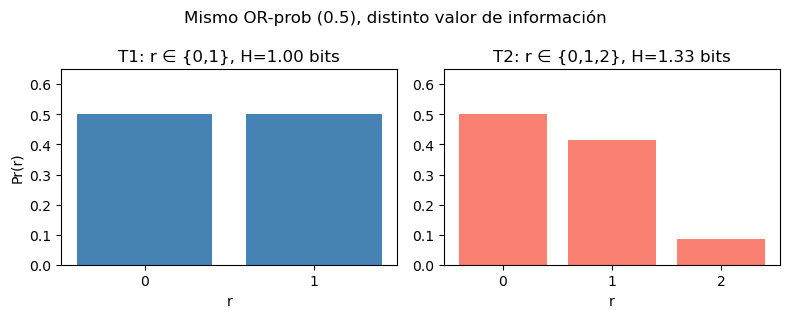

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].bar([0, 1], pmf1, color='steelblue')
ax[0].set_xticks([0, 1])
ax[0].set_title(f"T1: r ∈ {{0,1}}, H={H1:.2f} bits")
ax[0].set_xlabel("r")
ax[0].set_ylabel("Pr(r)")
ax[0].set_ylim(0, 0.65)
ax[1].bar([0, 1, 2], pmf2, color='salmon')
ax[1].set_xticks([0, 1, 2])
ax[1].set_title(f"T2: r ∈ {{0,1,2}}, H={H2:.2f} bits")
ax[1].set_xlabel("r")
ax[1].set_ylim(0, 0.65)
fig.suptitle("Mismo OR-prob (0.5), distinto valor de información")
fig.tight_layout()
plt.show()


## 6. ¿La formulación PWT cierra el lookahead gap?

Comparamos:
- **Greedy verdadero** (simulado, promediando sobre todos los $z$).
- **DP óptimo** (enumeración exacta).

Para $B \in \{2, 3\}$:

In [7]:
def greedy_true(p_prior, u, B, G, n):
    q = [1 - pi for pi in p_prior]
    total = 0.0
    for z in range(1 << n):
        w = 1.0
        for i in range(n):
            w *= p_prior[i] if (z >> i) & 1 else q[i]
        _, _, util_z = greedy_myopic_simulate(p_prior, u, B, G, z)
        total += w * util_z
    return total

rows = []
for B_eval in (2, 3):
    g = greedy_true(p_prior, u, B_eval, G, n)
    o, _ = solve_optimal_dapts(p_prior, u, B_eval, G)
    rows.append((B_eval, g, o, o - g))

print(f"{'B':>3} {'greedy(true)':>14} {'DP optimum':>14} {'gap':>10}")
for B_eval, g, o, gap in rows:
    print(f"{B_eval:>3} {g:>14.6f} {o:>14.6f} {gap:>+10.6f}")


  B   greedy(true)     DP optimum        gap
  2      18.441403      18.581749  +0.140346
  3      20.474029      22.433913  +1.959884


**Conclusión.** El gap **crece** con $B$ (de 0.14 a 1.96). El PWT
escalar es una *re-formulación* del objetivo myopic — no una nueva
política. Para cerrar este gap haría falta que $w_T$ cargara la PMF
completa del conteo, momento en que la formulación se vuelve
equivalente a la enumeración directa con DP exacto.

El valor potencial de PWT es entonces **teórico**: si se prueba
submodularidad adaptativa para $g_h(T, U) = E[u(\cdot) | h, t = T \cup U]$,
entonces una $\alpha$-aproximación por paso da una garantía global.
Esa prueba/refutación queda abierta.

## 7. Q3 — ¿Se puede restringir $W$ a top-L sin perder el óptimo?

$W$ tiene $2^{|S|}$ candidatos. Para hacer la enumeración práctica
necesitamos quedarnos con los más prometedores. Probamos varias
heurísticas:

- `self`: $(\sum u_T) \cdot \prod(1 - p_T)$ — valor del pool=T solo
- `prob`: $\prod(1 - p_T)$
- `util`: $\sum u_T$
- `ent_λ`: $\text{self}(T) + \lambda \cdot H(r_T)$ — aumentado con entropía
- `partner`: $(\sum u_T + u^*) \cdot \prod(1 - p_T) \cdot p^*$ donde
  $(u^*, p^*)$ es la utilidad/prob del **mejor pool de V de tamaño $G - |T|$**
  precomputado una sola vez
- `random`: baseline

Definimos $L_{\min}$ = el menor $L$ tal que el top-L (según la
heurística) contiene al $T^*$ óptimo.

In [8]:
res = restriction_experiment(p_post, S_idx, V_idx, u, G, rand_seed=0)
print(f"Sobre la instancia del paso 2 (|W| = {res['W_size']}):\n")
keys = sorted([k for k in res if k.startswith("L_min_")])
for k in keys:
    label = k.replace("L_min_", "")
    ratio = res[k] / res['W_size'] if res['W_size'] else 0
    print(f"  {label:<10}  L_min = {res[k]:>3}  ({ratio:.1%} of |W|)")


Sobre la instancia del paso 2 (|W| = 7):

  ent_1       L_min =   2  (28.6% of |W|)
  ent_25      L_min =   6  (85.7% of |W|)
  ent_5       L_min =   5  (71.4% of |W|)
  partner     L_min =   1  (14.3% of |W|)
  prob        L_min =   2  (28.6% of |W|)
  rand        L_min =   5  (71.4% of |W|)
  self        L_min =   2  (28.6% of |W|)
  util        L_min =   4  (57.1% of |W|)


## 8. Caso adversarial — donde `self` falla

Construimos a mano una instancia donde `self_score` requiere bajar
mucho en su ranking para encontrar el óptimo. Mecanismo:
incluir en $S$ un super-nodo "grande" cuyo $\sum u$ es alto pero
cuya $\prod(1 - p)$ baja arrastra el pool conjunto, mientras que un
$T$ singleton modesto, combinado con $V$, da el verdadero óptimo.

In [9]:
p_adv, S_adv, V_adv, u_adv, G_adv = adversarial_instance()
print(f"S = {S_adv}, V = {V_adv}, G = {G_adv}")
print(f"p = {p_adv}")
print(f"u = {u_adv}\n")

res_adv = restriction_experiment(p_adv, S_adv, V_adv, u_adv, G_adv,
                                 rand_seed=0)
print(f"|W| = {res_adv['W_size']}, val_full = {res_adv['val_full']:.4f}, "
      f"val_empty = {res_adv['val_empty']:.4f}\n")
keys_adv = sorted([k for k in res_adv if k.startswith("L_min_")])
for k in keys_adv:
    label = k.replace("L_min_", "")
    ratio = res_adv[k] / res_adv['W_size']
    print(f"  {label:<10}  L_min = {res_adv[k]:>3}  ({ratio:.1%} of |W|)")


S = [0, 1, 2, 3], V = [4, 5], G = 4
p = [0.01, 0.01, 0.6, 0.05, 0.05, 0.5]
u = [1.0, 1.0, 100.0, 50.0, 60.0, 80.0]

|W| = 15, val_full = 99.2750, val_empty = 66.5000

  ent_1       L_min =   8  (53.3% of |W|)
  ent_25      L_min =  12  (80.0% of |W|)
  ent_5       L_min =   8  (53.3% of |W|)
  partner     L_min =   2  (13.3% of |W|)
  prob        L_min =   4  (26.7% of |W|)
  rand        L_min =  15  (100.0% of |W|)
  self        L_min =   8  (53.3% of |W|)
  util        L_min =  12  (80.0% of |W|)


**Lectura del adversarial.**

- `self`: L_min = 8 — pésimo (53% de |W|)
- `partner`: L_min = 2 — robusto
- `entropy`: no ayuda — empata o peor que self

`partner` gana porque incorpora el costo de oportunidad de gastar
budget en $T$: si $|T|$ es grande, la mejor pareja $V$ disponible es
de tamaño $G - |T|$ y esa restricción aparece directamente en el
ranking.

## 9. Sweep — ¿`partner` aguanta en regímenes diversos?

Corremos K=20 trials por régimen sobre 6 regímenes (prevalencia baja,
alta, n grande, historia profunda, prevalencia bimodal, utilidad
heterogénea) y reportamos `mean / max` de $L_{\min}$.

In [10]:
print(f"{'regime':<40}  {'|W|':>6}  {'partner':>9}  {'self':>9}  "
      f"{'ent_1':>9}")
print(f"{'-'*40}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*9}")

regime_data = []
for spec in REGIMES:
    name, n_, G_, k_, pd, ud = spec
    out = run_regime(name, n_, G_, k_, pd, ud, K=20, base_seed=42)
    if out is None:
        continue
    regime_data.append(out)
    m, x = out["means"], out["maxes"]
    print(f"{name:<40}  {out['mean_W']:>6.1f}  "
          f"{m['L_min_partner']:>4.1f}/{x['L_min_partner']:<3}  "
          f"{m['L_min_self']:>4.1f}/{x['L_min_self']:<3}  "
          f"{m['L_min_ent_1']:>4.1f}/{x['L_min_ent_1']:<3}")


regime                                       |W|    partner       self      ent_1
----------------------------------------  ------  ---------  ---------  ---------
baseline (n=10,G=4,2-step,low p)            79.7   1.6/13    4.3/21    7.0/38 
high prevalence (n=10,G=4,p~U[0.4,0.7])     79.7   2.8/14    0.7/2     0.9/3  
larger n (n=15,G=5,2-step,low p)           278.3   1.1/4    12.7/132  18.2/184
deep history (n=10,G=3,3-step)              62.9   1.1/3     3.8/18    4.4/23 
bimodal p (10/90 mix of 0.05/0.7)           79.7   1.0/1     8.4/35    9.8/47 
outlier utility (u_0=50, rest U[1,10])      79.7   1.4/12    2.4/13    2.5/14 


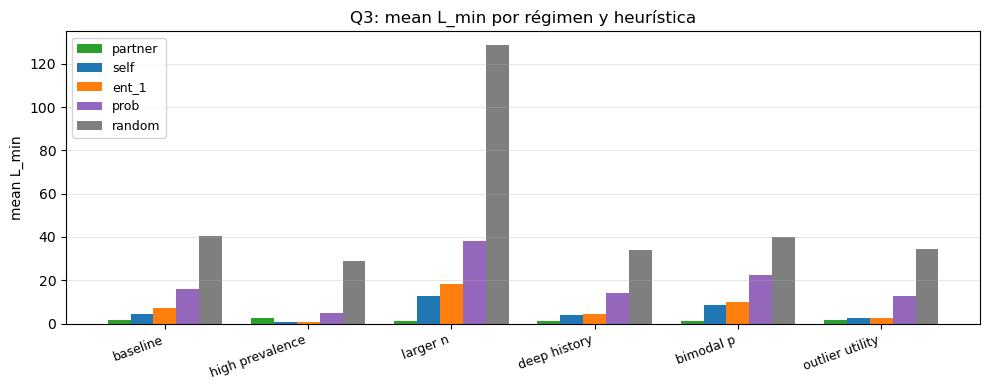

In [11]:
# Visualización: mean L_min por régimen
fig, ax = plt.subplots(figsize=(10, 4))
heur_keys = [("L_min_partner", "partner", "tab:green"),
             ("L_min_self", "self", "tab:blue"),
             ("L_min_ent_1", "ent_1", "tab:orange"),
             ("L_min_prob", "prob", "tab:purple"),
             ("L_min_rand", "random", "tab:gray")]
labels = [r["name"].split("(")[0].strip() for r in regime_data]
xs = np.arange(len(labels))
w_bar = 0.16
for i, (key, lab, color) in enumerate(heur_keys):
    vals = [r["means"][key] for r in regime_data]
    ax.bar(xs + i * w_bar - w_bar*2, vals, w_bar, label=lab, color=color)
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("mean L_min")
ax.set_title("Q3: mean L_min por régimen y heurística")
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


## 10. Conclusiones

**Lo que la formulación PWT da:**

1. **Equivalencia myopic exacta** con la lectura *all-clear*. El
   escalar $(|T|, \prod(1 - p), \sum u)$ basta para reproducir la
   decisión de un paso. Es una re-formulación útil para razonamiento
   teórico, no un algoritmo nuevo.
2. **Restricción computable**. La heurística `partner` reduce la
   enumeración de $|W| = 2^{|S|}$ a un top-L con $L \sim 1$–3 en
   promedio, en todos los regímenes empíricos probados — incluyendo
   $|W| \approx 280$. Eso convierte una operación exponencial en
   esencialmente constante en expectativa.

**Lo que NO da automáticamente:**

1. La formulación escalar **no cierra el lookahead gap**: el escalar
   es ciego a la PMF de conteo, que es donde vive la información de
   pasos futuros.
2. **No hay cota worst-case** sobre $L_{\min}$ con `partner` (en n=15
   vimos un trial con max = 4, pero teóricamente está abierto).
3. La submodularidad adaptativa de $g_h(T, U)$ con observación de
   conteo (Q4 en `docs/notes/pwt_submodularity.md`) sigue **abierta**.
   Sin ella no se compone una garantía global $\sim (1 - e^{-\alpha})$.

**Práctico:** PWT con `partner` y $L = 5$ es una implementación válida
del paso de Greedy Dynamic. **Teórico:** falta la prueba de
submodularidad adaptativa.
